1. Load data

In [30]:
import pandas as pd
import numpy as np

file_path = "../../data/raw/WESAD/S2/S2_respiban.txt"

ecg = pd.read_csv(
    file_path,
    sep="\t",        # change to " " if space-separated
    header=None,
    comment="#",     # ignores metadata lines starting with #
)

print(ecg.head())
print(ecg.shape)

   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN
3   3   0  30374  14701  32569  29553  37405  32341  31671  31076 NaN
4   4   0  30103  14684  32794  29561  37409  32342  31681  31365 NaN
(4442067, 11)


In [31]:
import pandas as pd

file_path =  "../../data/raw/WESAD/S2/S2_respiban.txt"

data = pd.read_csv(
    file_path,
    sep="\t",
    comment="#",        # ignores JSON header + metadata
    header=None,
    engine="python"
)

print(data.shape)
print(data.head())

(4442067, 11)
   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN
3   3   0  30374  14701  32569  29553  37405  32341  31671  31076 NaN
4   4   0  30103  14684  32794  29561  37409  32342  31681  31365 NaN


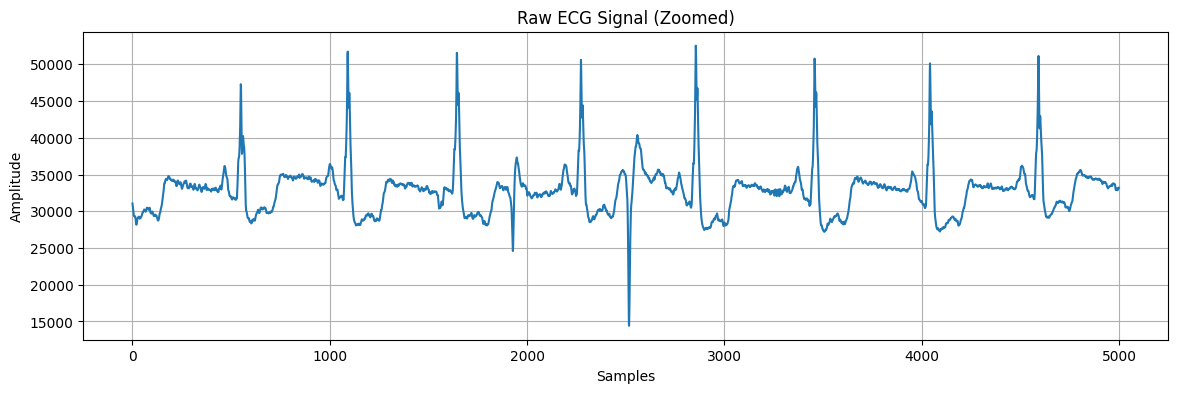

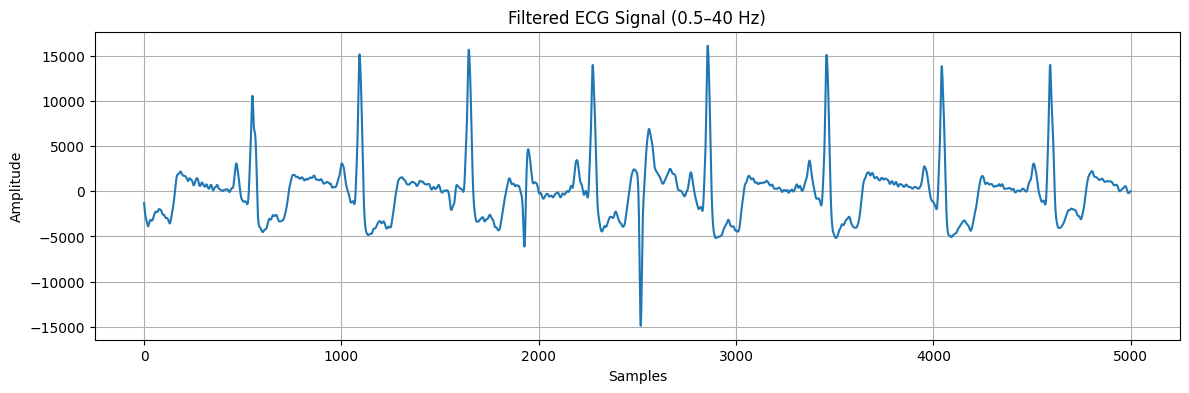

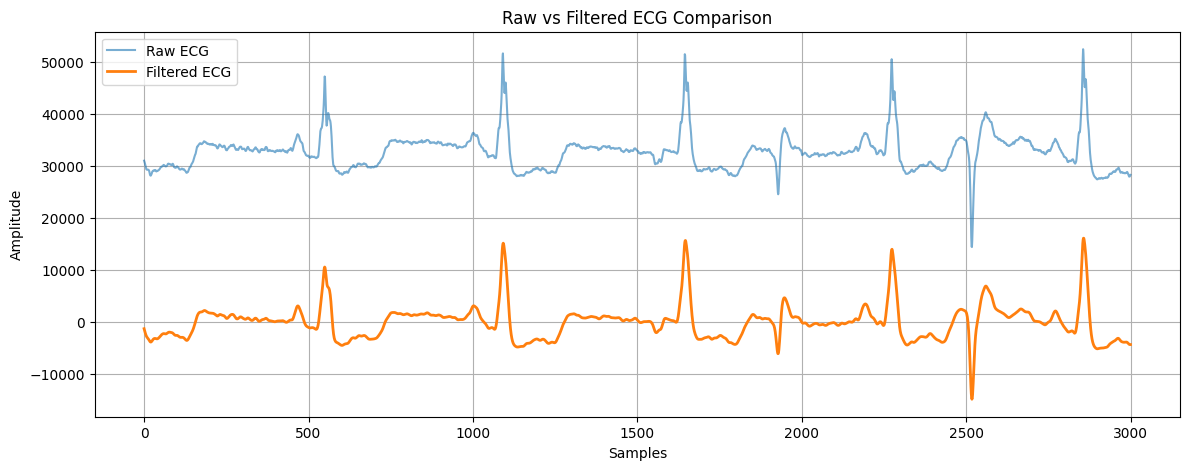

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# -----------------------------
# STEP 1: Extract ECG
# -----------------------------
ecg = data.iloc[:, 2].values   # CH1 as ECG (change if needed)

# -----------------------------
# STEP 2: Bandpass Filter (0.5–40 Hz)
# -----------------------------
def bandpass_filter(signal, fs=700, low=0.5, high=40, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

ecg_filtered = bandpass_filter(ecg)

# -----------------------------
# STEP 3: Plot RAW ECG
# -----------------------------
plt.figure(figsize=(14,4))
plt.plot(ecg[:5000])
plt.title("Raw ECG Signal (Zoomed)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# -----------------------------
# STEP 4: Plot FILTERED ECG
# -----------------------------
plt.figure(figsize=(14,4))
plt.plot(ecg_filtered[:5000])
plt.title("Filtered ECG Signal (0.5–40 Hz)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# -----------------------------
# STEP 5: COMPARISON PLOT
# -----------------------------
plt.figure(figsize=(14,5))
plt.plot(ecg[:3000], label="Raw ECG", alpha=0.6)
plt.plot(ecg_filtered[:3000], label="Filtered ECG", linewidth=2)
plt.title("Raw vs Filtered ECG Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

In [33]:
noise_raw = np.std(np.diff(ecg))
noise_filt = np.std(np.diff(ecg_filtered))

smooth_raw = np.mean(np.abs(np.diff(ecg)))
smooth_filt = np.mean(np.abs(np.diff(ecg_filtered)))

def outliers(signal):
    z = np.abs((signal - np.mean(signal)) / np.std(signal))
    return np.sum(z > 3)

out_raw = outliers(ecg)
out_filt = outliers(ecg_filtered)

snr_raw = np.mean(ecg) / np.std(ecg)
snr_filt = np.mean(ecg_filtered) / np.std(ecg_filtered)

print("\n===== ECG QUALITY METRICS =====")

print(f"Noise (diff std)     | Raw: {noise_raw:.5f} | Filtered: {noise_filt:.5f}")
print(f"Baseline drift       | Raw: {baseline_raw:.5f} | Filtered: {baseline_filt:.5f}")
print(f"Smoothness           | Raw: {smooth_raw:.5f} | Filtered: {smooth_filt:.5f}")
print(f"Outliers (>3z)       | Raw: {out_raw} | Filtered: {out_filt}")
print(f"SNR proxy            | Raw: {snr_raw:.5f} | Filtered: {snr_filt:.5f}")


===== ECG QUALITY METRICS =====
Noise (diff std)     | Raw: 345.33870 | Filtered: 221.83947


NameError: name 'baseline_raw' is not defined

In [ ]:
import numpy as np
from scipy.signal import find_peaks
# use FILTERED ECG (important)
signal = ecg_filtered

# peak detection
peaks, _ = find_peaks(
    signal,
    distance=700*0.6,      # minimum 0.6 sec between beats (~100 BPM max)
    prominence=0.5         # adjust if needed (important parameter)
)

print("R-peaks count:", len(peaks))
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(signal[:5000], label="ECG")
plt.scatter(peaks[peaks < 5000], signal[peaks[peaks < 5000]], 
            color='red', label="R-peaks")

plt.title("ECG with R-peaks")
plt.legend()
plt.grid()
plt.show()

In [ ]:
fs = 700  # sampling rate

rr_intervals = np.diff(peaks) / fs   # in seconds

print("RR intervals (first 10):", rr_intervals[:10])
print("\n===== RR INTERVAL STATS =====")
print("Mean RR (s):", np.mean(rr_intervals))
print("Std RR  (s):", np.std(rr_intervals))
print("Min RR  (s):", np.min(rr_intervals))
print("Max RR  (s):", np.max(rr_intervals))